#ML FINAL EXAM

### Email: rakibulhassanratulkhan84@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:

Dataset Overview

I chose the Diabetes dataset because it contains medical information that can be used to predict whether a person has diabetes. The dataset contains 768 records and 8 input features. I observed that all features are numerical and some features contain zero values that may represent missing or invalid measurements.



# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

##Answer:

1.Feature:8 feature and 1 target variable

2.Problem:This is  a classification problem because  the target variable cantains two classes:
  0= No diabetes
  1=Diabetes
Therefore ,the task is to classify each person into one of two categories.

3.Data points:768 entries

4.Null values:No actual Null value in the original dataset.

5.Feature types: All 8 input features are Quantitative features.There are no categorical input features.

6.Encoding:No categorical encoding is required because all input features are numerical.

7.Correlation:Glucose shows an important positive relationship with the diabetes outcome. BMI, age and the diabetes pedigree function also provide useful information for prediction.

8.EDA: From the EDA, people with higher glucose levels generally show a greater presence of the positive diabetes class. BMI and age also show useful variation between the two classes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#df=pd.read_csv("diabetes.csv")
df = pd.read_csv("sample_data/diabetes.csv")
print("Dataset Shape:",df.shape)
print("\n FIrst 10 rows:")
print(df.head(10))

display("\n data types:")
print(df.dtypes)

print("\n Missing Values:")
print(df.isnull().sum())

print("\Target Distribution:")
print(df["Class variable"].value_counts())




Dataset Shape: (768, 9)

 FIrst 10 rows:
   Number of times pregnant  \
0                         6   
1                         1   
2                         8   
3                         1   
4                         0   
5                         5   
6                         3   
7                        10   
8                         2   
9                         8   

   Plasma glucose concentration a 2 hours in an oral glucose tolerance test  \
0                                                148                          
1                                                 85                          
2                                                183                          
3                                                 89                          
4                                                137                          
5                                                116                          
6                                                 78            

<>:18: SyntaxWarning: invalid escape sequence '\T'
<>:18: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_997/1501609262.py:18: SyntaxWarning: invalid escape sequence '\T'
  print("\Target Distribution:")


'\n data types:'

Number of times pregnant                                                      int64
Plasma glucose concentration a 2 hours in an oral glucose tolerance test      int64
Diastolic blood pressure (mm Hg)                                              int64
Triceps skin fold thickness (mm)                                              int64
2-Hour serum insulin (mu U/ml)                                                int64
Body mass index (weight in kg/(height in m)^2)                              float64
Diabetes pedigree function                                                  float64
Age (years)                                                                   int64
Class variable                                                                int64
dtype: object

 Missing Values:
Number of times pregnant                                                    0
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0
Diastolic blood pressure (mm Hg)                        

Correlation + EDA code

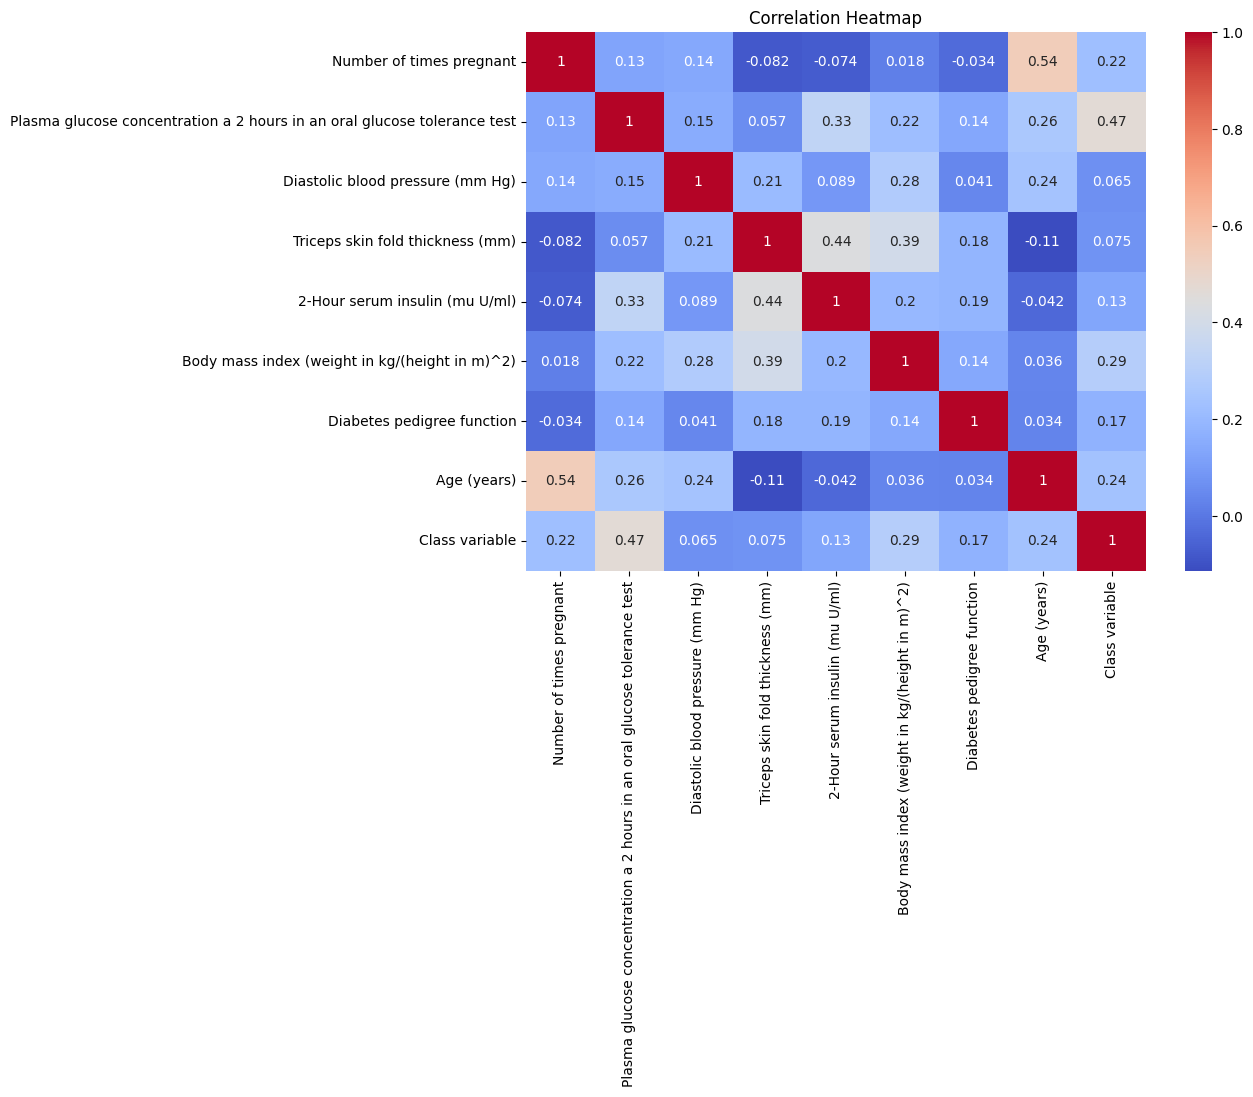

In [ ]:
#correlation matrix
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

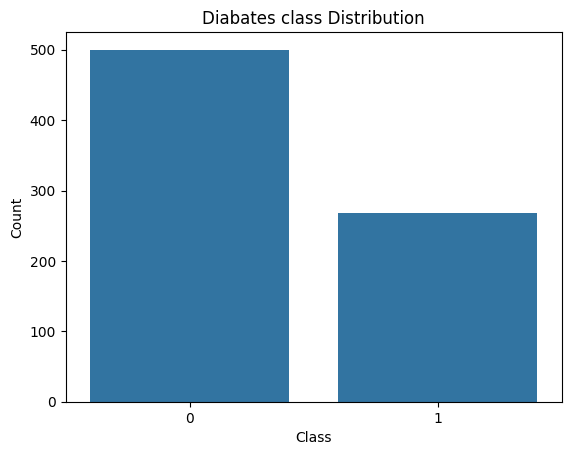

In [ ]:
#target distribution
sns.countplot(x="Class variable",data=df)
plt.title("Diabates class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

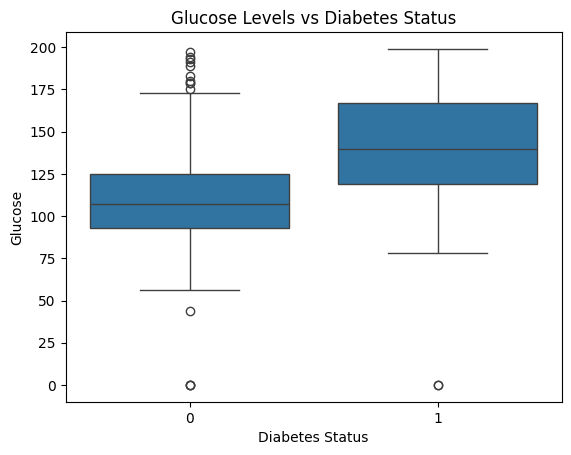

In [ ]:
#Glucose vs Diabetes
sns.boxplot(x="Class variable",y="Plasma glucose concentration a 2 hours in an oral glucose tolerance test",data=df)
plt.title("Glucose Levels vs Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Glucose")
plt.show()

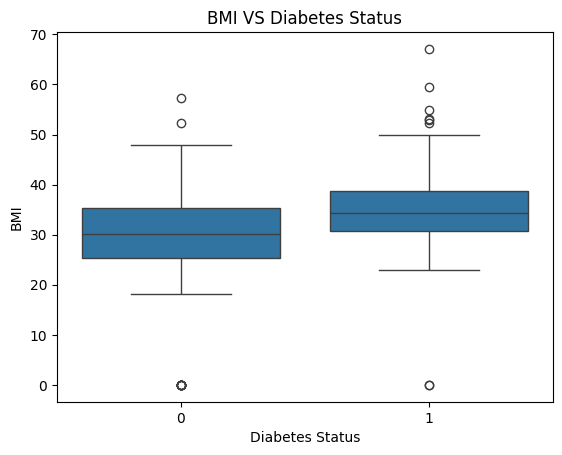

In [ ]:
#BMI vs Diabetes
sns.boxplot(x="Class variable",y="Body mass index (weight in kg/(height in m)^2)",data=df)
plt.title("BMI VS Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.show()

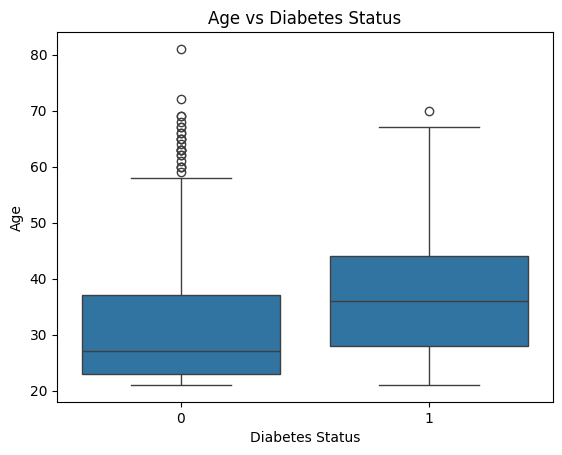

In [ ]:
#Age vs Diabetes
sns.boxplot(x="Class variable",y="Age (years)",data=df)
plt.title("Age vs Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Age")
plt.show()

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [ ]:
#1.Provide code
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

x=df.drop("Class variable",axis=1)
y=df["Class variable"]

zero_as_missing = ["Plasma glucose concentration a 2 hours in an oral glucose tolerance test", "Diastolic blood pressure (mm Hg)", "Triceps skin fold thickness (mm)", "2-Hour serum insulin (mu U/ml)", "Body mass index (weight in kg/(height in m)^2)"]

x[zero_as_missing] = x[zero_as_missing].replace(0, np.nan)

print("Missing Values after replacing 0 with NaN:")
print(x.isnull().sum())


Missing Values after replacing 0 with NaN:
Number of times pregnant                                                      0
Plasma glucose concentration a 2 hours in an oral glucose tolerance test      5
Diastolic blood pressure (mm Hg)                                             35
Triceps skin fold thickness (mm)                                            227
2-Hour serum insulin (mu U/ml)                                              374
Body mass index (weight in kg/(height in m)^2)                               11
Diabetes pedigree function                                                    0
Age (years)                                                                   0
dtype: int64


#2. Discuss the pre processing steps you applied and why?

answer:

1. Separate features and target: I separated the input features from the target variable Class variable.

2. Handle invalid zero values: Zero values in glucose, blood pressure, skin thickness, insulin and BMI were replaced with NaN because zero can represent missing or invalid medical measurements.

3. Missing value imputation: Median imputation was used to fill missing values because the median is less affected by extreme values.

4. Feature scaling: StandardScaler was used to bring the numerical features to a similar scale. This is especially useful for Logistic Regression.


#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



I decided to keep all 8 features because each feature may provide useful information for predicting diabetes. I did not drop any feature because the dataset is relatively small and every feature may contribute to the prediction.The dataset is divided into  80% training data  and 20 testing data

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

i also selected

1.Logistic Regression

2.Random Forest Classifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logistic_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler()),
    ("classifier",LogisticRegression())
])
random_forest_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler()),
    ("classifier",RandomForestClassifier())
])


# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [ ]:
logistic_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [ ]:
random_forest_pipeline.fit(x_train,y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier())])

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report

models={
    "LogisticRegression":logistic_pipeline,
    "RandomForestClassifier":random_forest_pipeline
}
result=[]

for name,model in models.items():
    y_pred=model.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)

    result.append({
        "Model":name,
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,

    })
results_df=pd.DataFrame(result)
display(results_df)


,Model,Accuracy,Precision,Recall
0,LogisticRegression,0.753247,0.666667,0.618182
1,RandomForestClassifier,0.766234,0.672727,0.672727


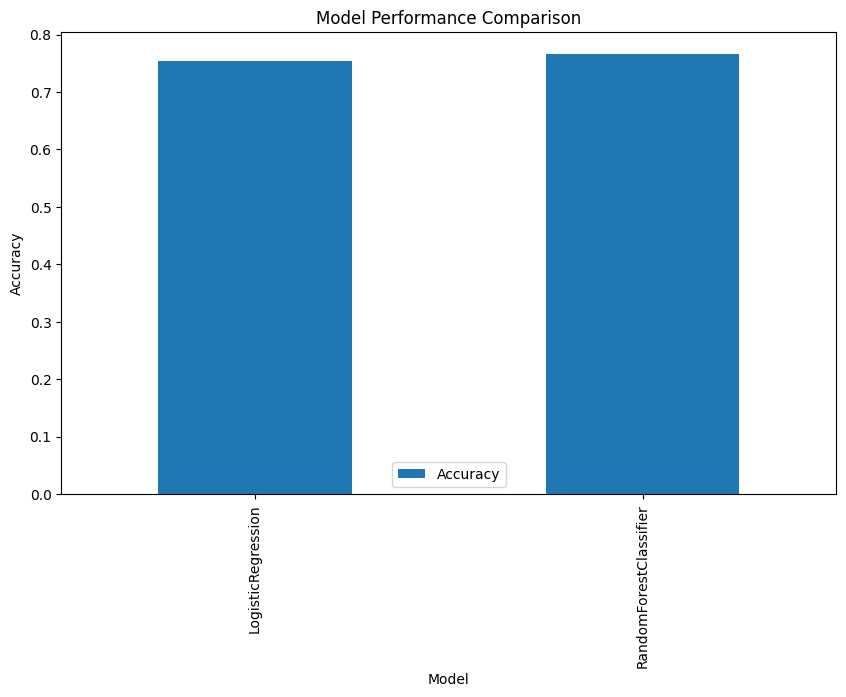

In [ ]:
#bar chart
results_df.plot(x="Model",y=["Accuracy"],kind="bar",figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

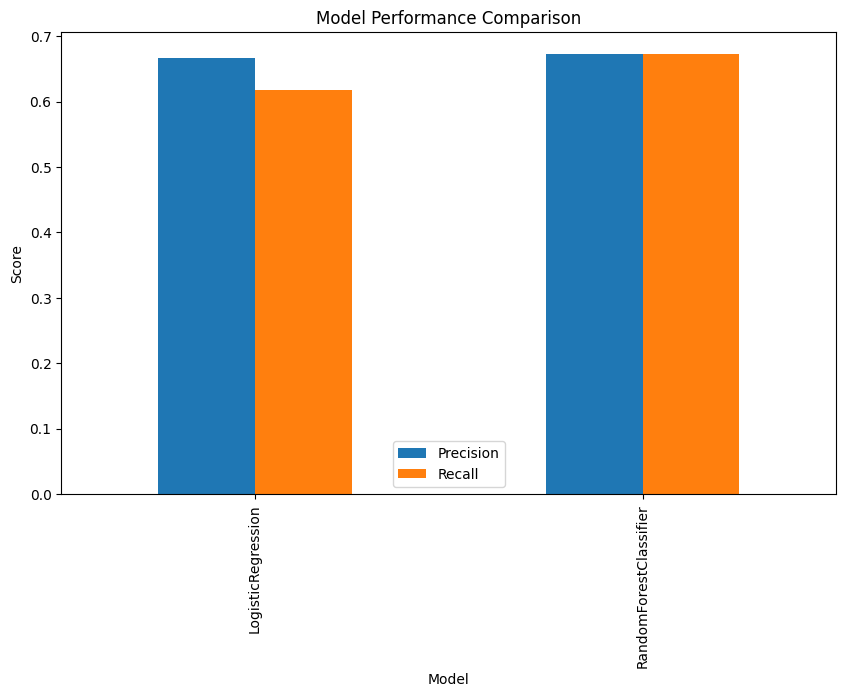

In [ ]:
#precision-recall curve
results_df.plot(x="Model",y=["Precision","Recall"],kind="bar",figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.show()

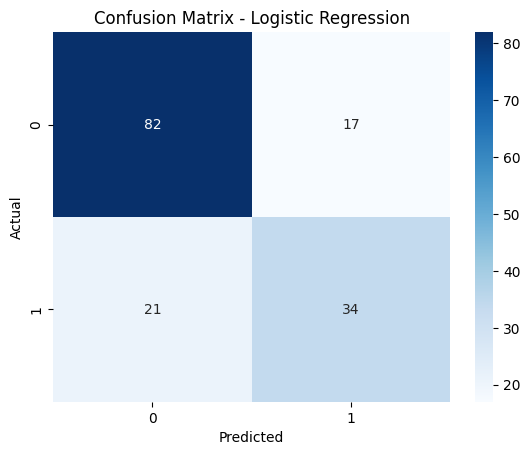

In [ ]:
#confusion matrix for Logistic Regression
sns.heatmap(confusion_matrix(y_test,logistic_pipeline.predict(x_test)),annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

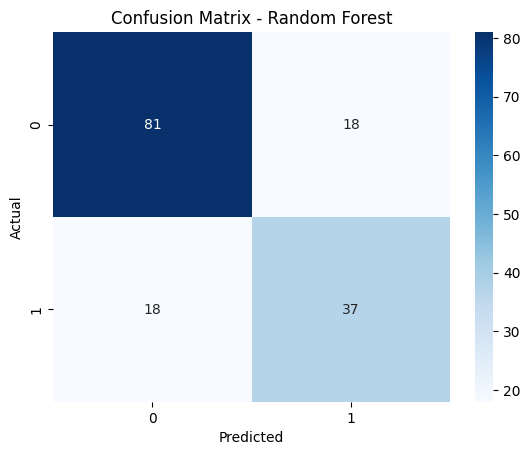

In [ ]:
#confusion matrix  for Random Forest
sns.heatmap(confusion_matrix(y_test,random_forest_pipeline.predict(x_test)),annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Answer :

Logistic Regression accuracy  75.32%, Precision 66.67% and Recall 61.81%

Random Forest accuracy  76.62%, Precision is 67.27% and Recall is 67.27%.

Random Forest produced higher values for accuracy,precision and recall
one possible reason is that Random Forest can model nonlinear relationships between different madical features.


# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,adjusted_rand_score

x_unsupervised=x.copy()

imputer=SimpleImputer(strategy="median")
x_unsupervised=imputer.fit_transform(x_unsupervised)

scaler=StandardScaler()
x_unsupervised=scaler.fit_transform(x_unsupervised)

kmeans=KMeans(n_clusters=2,random_state=42)
kmeans.fit(x_unsupervised)

cluster=kmeans.predict(x_unsupervised)

silhouette=silhouette_score(x_unsupervised,cluster)
ari=adjusted_rand_score(y,cluster)

print("Silhouette Score:",silhouette)
print("Adjusted Rand Index:",ari)


Silhouette Score: 0.19627861483317974
Adjusted Rand Index: 0.16137851600091285


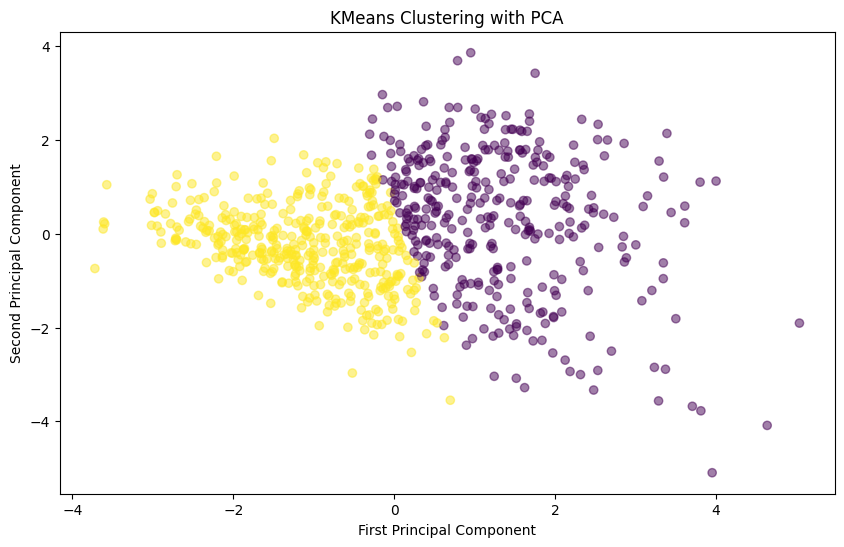

In [ ]:
#visualization of clusters using PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_unsupervised)

plt.figure(figsize=(10,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=cluster,cmap="viridis",alpha=0.5)
plt.title("KMeans Clustering with PCA")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.show()

In [ ]:
comparison=pd.crosstab(y,cluster,rownames=["Actual"],colnames=["Predicted"])
print(comparison)

Predicted    0    1
Actual             
0          156  344
1          195   73


# Answer:

The supervised approach is more suitable for this dataset because the dataset already provides a target variable indicating whether each person belongs to the diabetic or non-diabetic class

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:


Easiest Topic – Linear Regression:

Linear Regression was the easiest topic for me because it is simple to understand. It finds the relationship between input and output and draws the best-fit line to make predictions. For example, we can use a person's study hours to predict their exam marks. It is useful for predicting continuous values such as salary, house price, or sales.

Hardest Topic – DBSCAN Clustering:

DBSCAN was the hardest topic for me because it is an unsupervised clustering algorithm and its concepts like core points, border points, noise points, ε (epsilon), and MinPts were difficult to understand at first. Unlike Linear Regression, there is no target value, so the algorithm finds groups based on the density of data points. In real life, DBSCAN can be used to detect unusual transactions, identify groups of customers, or detect abnormal locations in GPS data.

